# CNN Lab Assignment
## Task 1 — Convolutional Neural Networks

**Name:** Shashank  
**Roll Number:** 24IT3056  
**Course:** Machine Learning / Deep Learning  
**Framework:** TensorFlow / Keras  

---

In [7]:
import os, random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

In [8]:
print("TF:", tf.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)
    print("GPU:", gpus[0].name)
else:
    print("no GPU — CPU only")

TF: 2.10.0
NumPy: 1.26.4
Pandas: 2.3.3
GPU: /physical_device:GPU:0


In [9]:
(x_tr_m, y_tr_m), (x_te_m, y_te_m) = mnist.load_data()
(x_tr_c, y_tr_c), (x_te_c, y_te_c) = cifar10.load_data()

print("MNIST  train:", x_tr_m.shape, y_tr_m.shape)
print("MNIST  test :", x_te_m.shape, y_te_m.shape)
print("CIFAR  train:", x_tr_c.shape, y_tr_c.shape)
print("CIFAR  test :", x_te_c.shape, y_te_c.shape)
print("MNIST  dtype:", x_tr_m.dtype, "range:", x_tr_m.min(), x_tr_m.max())
print("CIFAR  dtype:", x_tr_c.dtype, "range:", x_tr_c.min(), x_tr_c.max())

counts = np.bincount(y_tr_m)
print("MNIST class counts:", {i: counts[i] for i in range(10)})

MNIST  train: (60000, 28, 28) (60000,)
MNIST  test : (10000, 28, 28) (10000,)
CIFAR  train: (50000, 32, 32, 3) (50000, 1)
CIFAR  test : (10000, 32, 32, 3) (10000, 1)
MNIST  dtype: uint8 range: 0 255
CIFAR  dtype: uint8 range: 0 255
MNIST class counts: {0: 5923, 1: 6742, 2: 5958, 3: 6131, 4: 5842, 5: 5421, 6: 5918, 7: 6265, 8: 5851, 9: 5949}


## Problem 2 — Observations

- MNIST train: (60000, 28, 28) | test: (10000, 28, 28)
- CIFAR train: (50000, 32, 32, 3) | test: (10000, 32, 32, 3)
- both dtype: uint8, range: 0–255 before processing
- MNIST class counts: 5923–6742 per class, roughly balanced
- class 1 has most (6742), class 5 has least (5421)

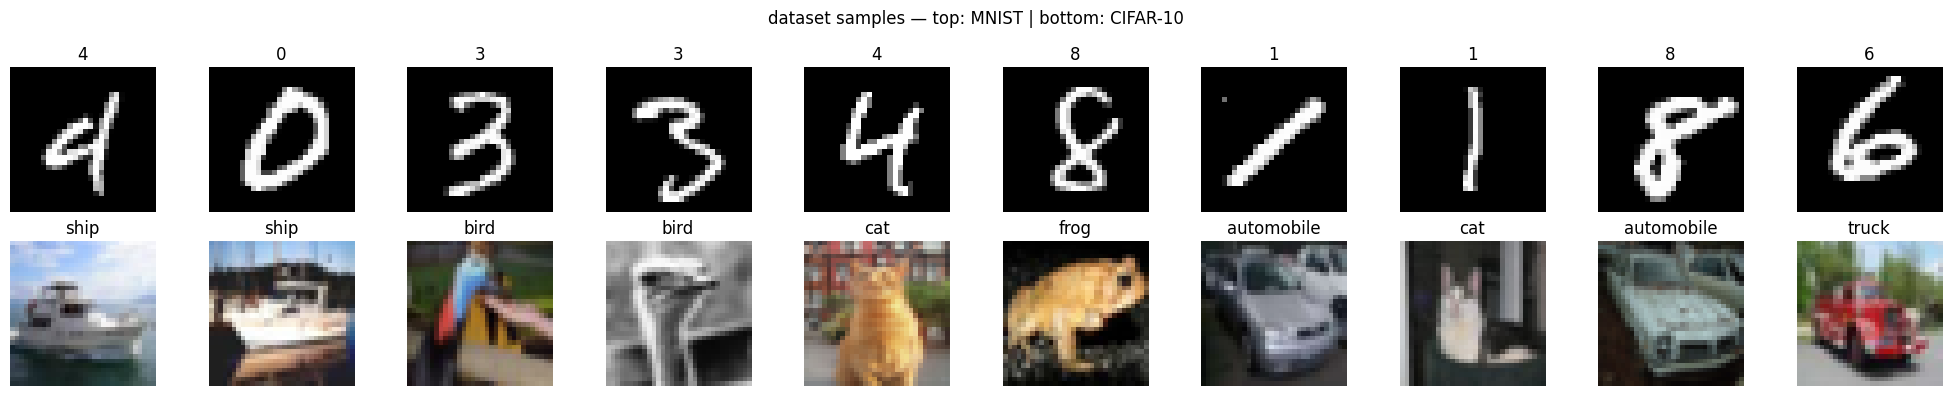

In [10]:
CNAMES = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

fig, axes = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    idx = np.random.randint(len(x_tr_m))
    axes[0,i].imshow(x_tr_m[idx], cmap='gray')
    axes[0,i].set_title(str(y_tr_m[idx])); axes[0,i].axis('off')
    idx = np.random.randint(len(x_tr_c))
    axes[1,i].imshow(x_tr_c[idx])
    axes[1,i].set_title(CNAMES[y_tr_c[idx][0]]); axes[1,i].axis('off')

plt.suptitle("dataset samples — top: MNIST | bottom: CIFAR-10")
plt.tight_layout()
plt.savefig("dataset_samples.png", dpi=100)
plt.show()

In [11]:
def preprocess(X, y, is_mnist=False):
    print("Before — shape:", X.shape, "dtype:", X.dtype, "range:", X.min(), X.max())
    X = X.astype('float32') / 255.0
    if is_mnist:
        X = np.expand_dims(X, -1)
    y = to_categorical(y, 10)
    print("After  — shape:", X.shape, "dtype:", X.dtype, "range:", X.min(), X.max())
    print("label sample:", y[0])
    return X, y

x_tr_m_p, y_tr_m_p = preprocess(x_tr_m, y_tr_m, is_mnist=True)
x_te_m_p, y_te_m_p = preprocess(x_te_m, y_te_m, is_mnist=True)
x_tr_c_p, y_tr_c_p = preprocess(x_tr_c, y_tr_c.flatten())
x_te_c_p, y_te_c_p = preprocess(x_te_c, y_te_c.flatten())

Before — shape: (60000, 28, 28) dtype: uint8 range: 0 255
After  — shape: (60000, 28, 28, 1) dtype: float32 range: 0.0 1.0
label sample: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
Before — shape: (10000, 28, 28) dtype: uint8 range: 0 255
After  — shape: (10000, 28, 28, 1) dtype: float32 range: 0.0 1.0
label sample: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
Before — shape: (50000, 32, 32, 3) dtype: uint8 range: 0 255
After  — shape: (50000, 32, 32, 3) dtype: float32 range: 0.0 1.0
label sample: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
Before — shape: (10000, 32, 32, 3) dtype: uint8 range: 0 255
After  — shape: (10000, 32, 32, 3) dtype: float32 range: 0.0 1.0
label sample: [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]


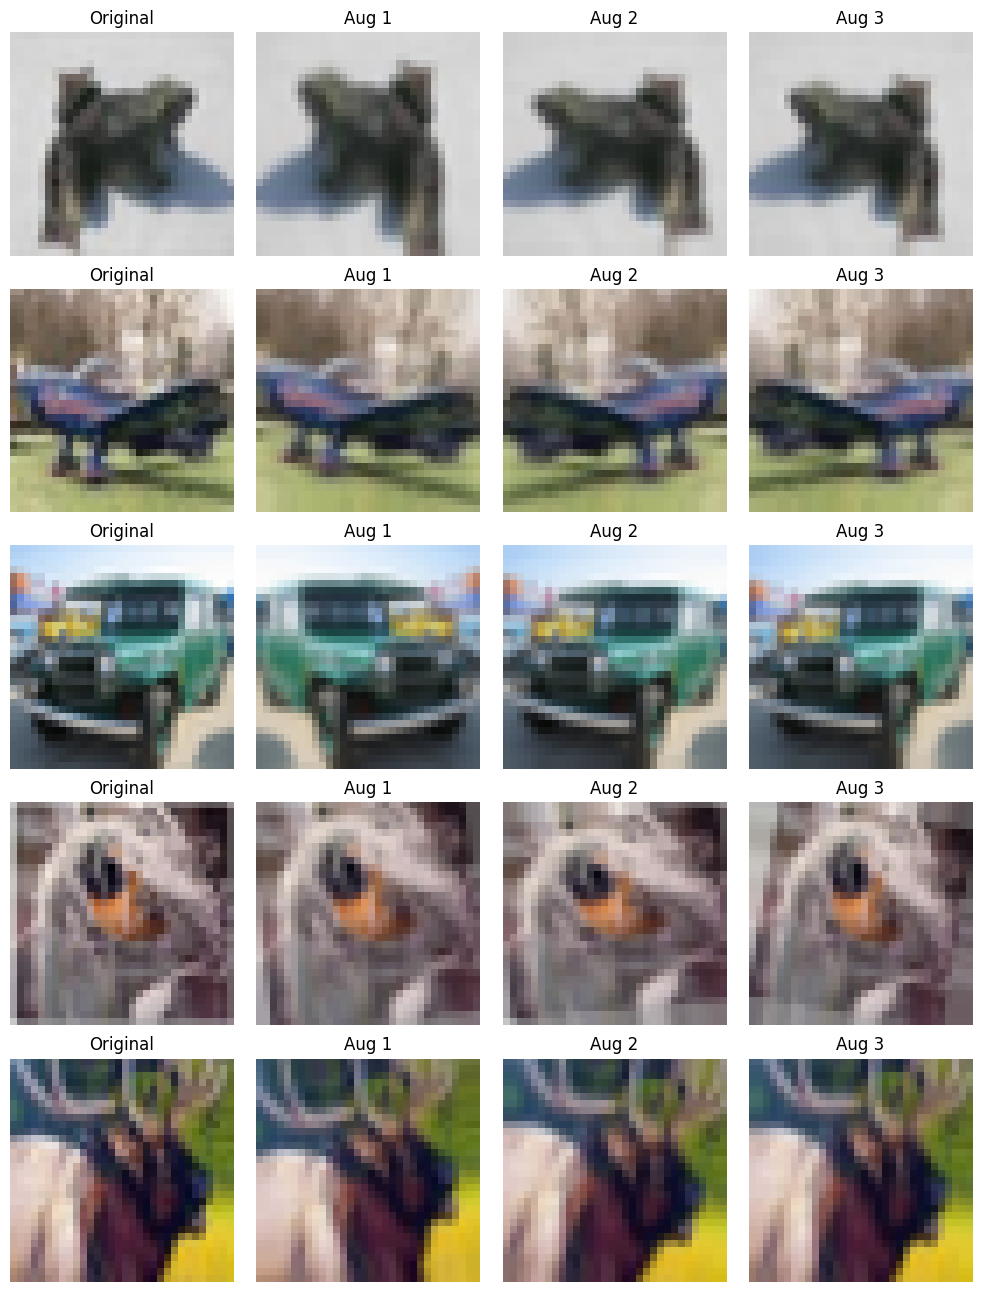

In [12]:
datagen = ImageDataGenerator(
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.1
)

fig, axes = plt.subplots(5, 4, figsize=(10, 13))
for row in range(5):
    orig = x_tr_c_p[np.random.randint(len(x_tr_c_p))]
    axes[row,0].imshow(orig); axes[row,0].set_title("Original"); axes[row,0].axis('off')
    gen = datagen.flow(orig[np.newaxis], batch_size=1)
    for col in range(1, 4):
        axes[row,col].imshow(next(gen)[0].clip(0,1))
        axes[row,col].set_title(f"Aug {col}"); axes[row,col].axis('off')

plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=100)
plt.show()

## Problem 4 — Augmentation Justification

- val and test sets must reflect unchanged real-world distribution
- augmenting them inflates evaluation scores artificially
- augmentation is a training-only regularisation technique
- for MNIST: no horizontal flips — flipped 6 looks like 9 (label changes)

## Analysis Questions

**Q1.**
- C in (N,H,W,C) = channel dimension
- greyscale: C=1 — one intensity value per pixel
- RGB: C=3 — red, green, blue stacked along last axis
- each conv filter learns weights across all C channels at once

**Q2.**
- patch-based loading — tile 1024×1024 into 256×256 chunks, load one at a time
- tf.data prefetch — stream from disk with .prefetch(AUTOTUNE), overlaps loading with GPU compute

**Q3.**
- using test set stats to normalise test = data leakage
- test must simulate unseen data — its distribution should be unknown
- correct: compute mean/std on train only, apply same values to val and test